<a href="https://colab.research.google.com/github/areebaeman234-ux/ML-Internship/blob/main/Copy_of_w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
# ============================================
# WEEK 7 — SETUP
# ============================================

!pip install -q duckdb pyarrow pandas numpy matplotlib

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import userdata

# Output folders
OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# DuckDB connection
con = duckdb.connect()

# Hugging Face token
hf_token = userdata.get("hf_token")

con.execute(
    f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')"
)

print("Setup complete.")

Setup complete.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
# ============================================
# LOAD MARCH DEVELOPMENT DATA
# ============================================

query = """
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position,
    gsc_data_available
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
)
WHERE month = '2026-03'
  AND gsc_data_available = TRUE
"""

df = con.execute(query).df()

print("Rows:", len(df))
print("Clients:", df["client_hash_id"].nunique())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 3611061
Clients: 47


In [ ]:
# ============================================
# PAGE-LEVEL AGGREGATION
# ============================================

page_query = """
SELECT
    client_hash_id,
    content_hash_id,

    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,

    SUM(gsc_clicks) / NULLIF(SUM(gsc_impressions), 0)
        AS ctr,

    SUM(gsc_sum_position) / NULLIF(SUM(gsc_impressions), 0)
        AS avg_position

FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
)

WHERE month = '2026-03'
  AND gsc_data_available = TRUE

GROUP BY
    client_hash_id,
    content_hash_id

HAVING SUM(gsc_impressions) > 0
"""

pages = con.execute(page_query).df()

pages["ctr"] = pages["ctr"].fillna(0)
pages["avg_position"] = pages["avg_position"].fillna(999)

print("Page-level rows:", len(pages))
pages.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Page-level rows: 176738


,client_hash_id,content_hash_id,impressions,clicks,ctr,avg_position
0,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,1140.0,2.0,0.001754,4.450877
1,client_73cda7b4e4f265ea,content_05597932fe4da067,57.0,0.0,0.000000,2.298246
2,client_73cda7b4e4f265ea,content_905aa32a0230694e,149.0,0.0,0.000000,5.637584
3,client_73cda7b4e4f265ea,content_05434271b257bb68,1421.0,6.0,0.004222,6.906404
4,client_73cda7b4e4f265ea,content_d056587ff7faca0c,2770.0,16.0,0.005776,3.950542


In [ ]:
# ============================================
# TRANSPARENT OPPORTUNITY SCORE
# ============================================

# Exposure component
pages["impression_rank"] = (
    pages["impressions"]
    .rank(pct=True)
)

# Lower position number = better search position.
# Convert it so stronger positions receive a higher score.
pages["position_score"] = (
    1 - pages["avg_position"].rank(pct=True)
)

# Lower CTR receives a higher review priority.
pages["ctr_opportunity"] = (
    1 - pages["ctr"].rank(pct=True)
)

# Transparent weighted score.
pages["opportunity_score"] = (
    0.40 * pages["impression_rank"]
    + 0.35 * pages["position_score"]
    + 0.25 * pages["ctr_opportunity"]
)

pages = pages.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

print("Opportunity score created.")
pages[
    [
        "content_hash_id",
        "impressions",
        "ctr",
        "avg_position",
        "opportunity_score"
    ]
].head(10)

Opportunity score created.


,content_hash_id,impressions,ctr,avg_position,opportunity_score
0,content_bf078007df823490,44707.0,0.0,1.400049,0.913023
1,content_520e203a08cd69ee,10462.0,0.0,0.229593,0.908199
2,content_fa17add7836d36c3,12588.0,0.0,1.141246,0.906161
3,content_83167156f76e33e5,6827.0,0.0,1.003076,0.895069
4,content_1fdd52456a5d3f20,7329.0,0.0,1.389275,0.894409
5,content_b154f6c2652cfeb9,11344.0,0.0,2.012077,0.894400
6,content_d397987113cb84a0,9887.0,0.0,2.023465,0.891964
7,content_a27b382f00aa75c6,7736.0,0.0,1.863754,0.890808
8,content_fd1d19e381fc653e,4319.0,0.0,0.068303,0.884128
9,content_1bc8782404e3b132,5792.0,0.0,1.975483,0.882355


In [ ]:
# ============================================
# REASON CODES
# ============================================

# Dataset-level thresholds
high_impression = pages["impressions"].quantile(0.75)
low_ctr = pages["ctr"].quantile(0.25)
strong_position = pages["avg_position"].quantile(0.25)

def assign_reason(row):

    if (
        row["impressions"] >= high_impression
        and row["ctr"] <= low_ctr
        and row["avg_position"] <= strong_position
    ):
        return "HIGH_EXPOSURE_LOW_CTR"

    elif (
        row["impressions"] >= high_impression
        and row["ctr"] <= low_ctr
    ):
        return "HIGH_EXPOSURE_LOW_CTR"

    elif row["avg_position"] <= strong_position:
        return "POSITION_OPPORTUNITY"

    elif row["impressions"] >= high_impression:
        return "HIGH_EXPOSURE_REVIEW"

    else:
        return "LOW_PRIORITY_REVIEW"

pages["reason_code"] = pages.apply(
    assign_reason,
    axis=1
)

reason_actions = {
    "HIGH_EXPOSURE_LOW_CTR":
        "Review title, snippet alignment, and search intent",

    "POSITION_OPPORTUNITY":
        "Review whether the page and search intent are well aligned",

    "HIGH_EXPOSURE_REVIEW":
        "Review page performance and content relevance",

    "LOW_PRIORITY_REVIEW":
        "No immediate action; monitor before changing content"
}

pages["suggested_action"] = pages["reason_code"].map(
    reason_actions
)

pages["priority"] = np.arange(1, len(pages) + 1)

queue = pages[
    [
        "priority",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "opportunity_score",
        "reason_code",
        "suggested_action"
    ]
].copy()

queue.head(20)

,priority,client_hash_id,content_hash_id,impressions,clicks,ctr,avg_position,opportunity_score,reason_code,suggested_action
0,1,client_23a62021009f63c4,content_bf078007df823490,44707.0,0.0,0.0,1.400049,0.913023,HIGH_EXPOSURE_LOW_CTR,"Review title, snippet alignment, and search in..."
1,2,client_73cda7b4e4f265ea,content_520e203a08cd69ee,10462.0,0.0,0.0,0.229593,0.908199,HIGH_EXPOSURE_LOW_CTR,"Review title, snippet alignment, and search in..."
2,3,client_a80fca3f171ed1de,content_fa17add7836d36c3,12588.0,0.0,0.0,1.141246,0.906161,HIGH_EXPOSURE_LOW_CTR,"Review title, snippet alignment, and search in..."
3,4,client_e547b89c05043229,content_83167156f76e33e5,6827.0,0.0,0.0,1.003076,0.895069,HIGH_EXPOSURE_LOW_CTR,"Review title, snippet alignment, and search in..."
4,5,client_a80fca3f171ed1de,content_1fdd52456a5d3f20,7329.0,0.0,0.0,1.389275,0.894409,HIGH_EXPOSURE_LOW_CTR,"Review title, snippet alignment, and search in..."
5,6,client_73cda7b4e4f265ea,content_b154f6c2652cfeb9,11344.0,0.0,0.0,2.012077,0.894400,HIGH_EXPOSURE_LOW_CTR,"Review title, snippet alignment, and search in..."
6,7,client_73cda7b4e4f265ea,content_d397987113cb84a0,9887.0,0.0,0.0,2.023465,0.891964,HIGH_EXPOSURE_LOW_CTR,"Review title, snippet alignment, and search in..."
7,8,client_23a62021009f63c4,content_a27b382f00aa75c6,7736.0,0.0,0.0,1.863754,0.890808,HIGH_EXPOSURE_LOW_CTR,"Review title, snippet alignment, and search in..."
8,9,client_73cda7b4e4f265ea,content_fd1d19e381fc653e,4319.0,0.0,0.0,0.068303,0.884128,HIGH_EXPOSURE_LOW_CTR,"Review title, snippet alignment, and search in..."
9,10,client_fef1a8f436438636,content_1bc8782404e3b132,5792.0,0.0,0.0,1.975483,0.882355,HIGH_EXPOSURE_LOW_CTR,"Review title, snippet alignment, and search in..."


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
# ============================================
# WEEK 6 MODEL RECEIPT
# ============================================

model_receipt = pd.DataFrame({
    "Metric": [
        "Grouped Random Forest R2",
        "Grouped Baseline R2",
        "Grouped Random Forest MAE",
        "Grouped Baseline MAE"
    ],
    "Value": [
        -0.0370,
        -0.0001,
        0.001392,
        0.001410
    ]
})

model_receipt

,Metric,Value
0,Grouped Random Forest R2,-0.037000
1,Grouped Baseline R2,-0.000100
2,Grouped Random Forest MAE,0.001392
3,Grouped Baseline MAE,0.001410


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
# ============================================
# HUMAN REVIEW CHECKLIST
# ============================================

review_checklist = pd.DataFrame({
    "Review item": [
        "Enough search exposure?",
        "CTR pattern worth investigating?",
        "Search intent checked?",
        "Recent content change checked?",
        "Tracking/data quality checked?",
        "Proposed action is appropriate?",
        "Human approved action?"
    ],
    "Required": ["Yes"] * 7
})

review_checklist

,Review item,Required
0,Enough search exposure?,Yes
1,CTR pattern worth investigating?,Yes
2,Search intent checked?,Yes
3,Recent content change checked?,Yes
4,Tracking/data quality checked?,Yes
5,Proposed action is appropriate?,Yes
6,Human approved action?,Yes


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
# ============================================
# MONITORING SNAPSHOT
# ============================================

monitoring = pd.DataFrame({
    "metric": [
        "Number of pages",
        "Median impressions",
        "Median CTR",
        "Median average position",
        "High exposure / low CTR count",
        "Position opportunity count"
    ],
    "value": [
        len(queue),
        queue["impressions"].median(),
        queue["ctr"].median(),
        queue["avg_position"].median(),
        (queue["reason_code"] == "HIGH_EXPOSURE_LOW_CTR").sum(),
        (queue["reason_code"] == "POSITION_OPPORTUNITY").sum()
    ]
})

monitoring

,metric,value
0,Number of pages,176738.000000
1,Median impressions,173.000000
2,Median CTR,0.000000
3,Median average position,8.177966
4,High exposure / low CTR count,4145.000000
5,Position opportunity count,43350.000000


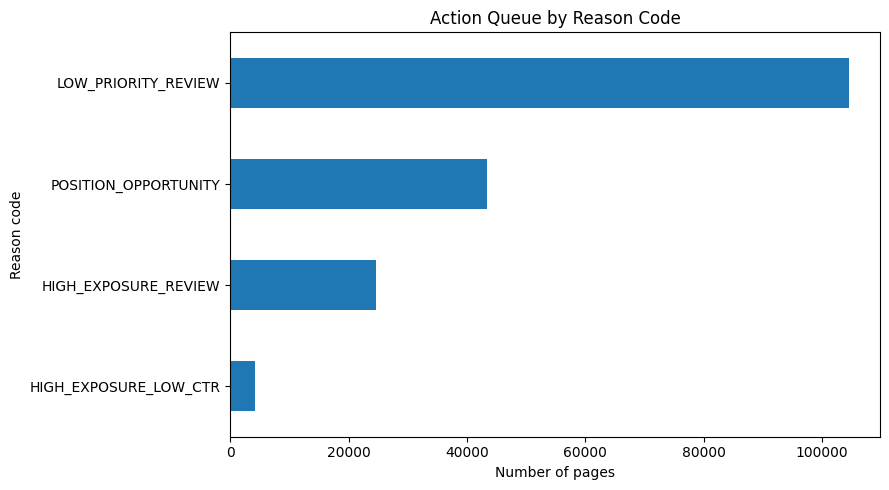

Saved: work/figures/w07_reason_code_distribution.png


In [ ]:
# ============================================
# REASON CODE DISTRIBUTION
# ============================================

reason_counts = (
    queue["reason_code"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
reason_counts.plot(kind="barh")
plt.xlabel("Number of pages")
plt.ylabel("Reason code")
plt.title("Action Queue by Reason Code")
plt.tight_layout()

figure_path = FIGURE_DIR / "w07_reason_code_distribution.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.